# Robust analysis

Even having a few outliers in training data can significantly distort calibration models. This notebook will walk through methods that help make analysis more resilient. In particular we will consider robust PC regression and robust PLSR.

## Loading the data

Let's load our data and select dry matter as the response variable as usual

In [218]:
import numpy as np

kiwi_spectra = np.loadtxt("results/kiwi_avg_spectra.csv", delimiter=",")
reference_values = np.loadtxt("data/reference.csv", delimiter=",")
wl = np.loadtxt("results/wavelengths.csv", delimiter=",")
reference_values = reference_values[:180, 0]
reference_values = np.expand_dims(reference_values, axis=1)
reference_values.shape

(180, 1)

## Pre-processing

Let's process our data in the same way as we did in spectral analysis notebook.

In [219]:
import nippy

preprocessing_pipeline = {'MSC': None, 
                          'SAVGOL': 
                          {'deriv_order': 2, 
                           'filter_win': 13, 
                           'poly_order': 2}, 
                           'SNV': {}}

wl, kiwi_spectra_processed = nippy.run_pipeline(wl, kiwi_spectra.T, preprocessing_pipeline)
kiwi_spectra_processed = kiwi_spectra_processed.T

## Data partition

Next let's divide our data into calibration and test set

In [220]:
import kennard_stone as ks

X_cal_ks, X_test_ks, y_cal_ks, y_test_ks = ks.train_test_split(kiwi_spectra_processed, reference_values, test_size = 0.2, random_state=1)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/kennard_stone/_core/_core.py:313: IgnoredArgumentWarning: `random_state` is unnecessary since it is uniquely determined in this algorithm.
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-07-04 14:53:47,801 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-07-04 14:53:47,804 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sk

## Robust PCA

PCA is very susceptible to the outliers. If we modify just one sample the results already are going to be quite different. Let's artificially introduce some outliers in our dataset and see how it influences the model.

In [221]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random

We'll select a few indices at random for X and y. For robust PCR we will only experiment with outliers in spectra since by design simple linear regression built on principal components cannot deal with outliers.

In [222]:
random.seed(42)
number_of_outliers_x = 5
number_of_outliers_y = 5
indices_of_outliers = random.sample(range(X_cal_ks.shape[0]), number_of_outliers_x + number_of_outliers_y)
indices_of_outliers_x = indices_of_outliers[:number_of_outliers_x]
indices_of_outliers_y = indices_of_outliers[number_of_outliers_x:]

In [223]:
X_copy = np.copy(X_cal_ks)
X_copy[indices_of_outliers_x,:] = X_copy[indices_of_outliers_x,:] * 5

In [224]:
pipe1 = Pipeline([('scaler', StandardScaler(with_std=False)), ('pca', PCA(random_state=42))])
pipe2 = Pipeline([('scaler', StandardScaler(with_std=False)), ('pca', PCA(random_state=42))])
 
pipe1.fit(X_cal_ks)
pipe2.fit(X_copy)

Pipeline(steps=[('scaler', StandardScaler(with_std=False)),
                ('pca', PCA(random_state=42))])

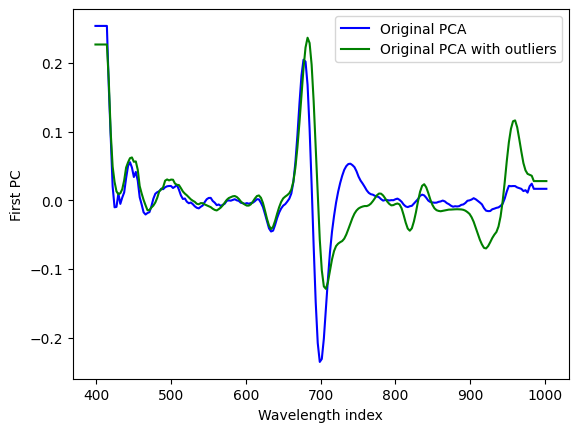

In [225]:
plt.plot(wl, pipe1["pca"].components_[0], 'b', label="Original PCA")
plt.plot(wl, pipe2["pca"].components_[0], 'g', label="Original PCA with outliers")
plt.ylabel("First PC")
plt.xlabel("Wavelength index")
 
plt.legend()
plt.show()

If we use robust way of estimating covariance, we can mitigate the effects of outliers. Try playing with the support fraction to get better results.

In [226]:
from sklearn.covariance import MinCovDet

# Fit MinCovDet on the data with outliers
robust_cov = MinCovDet(support_fraction=0.3, random_state=42).fit(X_copy)
V_robust = robust_cov.covariance_

# Calculate eigenvalues and eigenvectors of the robust covariance matrix
values_robust, vectors_robust = np.linalg.eig(V_robust)
sorted_values_robust = np.argsort(values_robust)[::-1]
sorted_vectors_robust = vectors_robust[:, sorted_values_robust]

first_pc_robust = sorted_vectors_robust[:, 0]
first_pc_robust /= np.linalg.norm(first_pc_robust)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


In [227]:
first_pc_robust *= -1 # Eigenvectors are unique up to a sign. Sometimes you might want to flip it

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


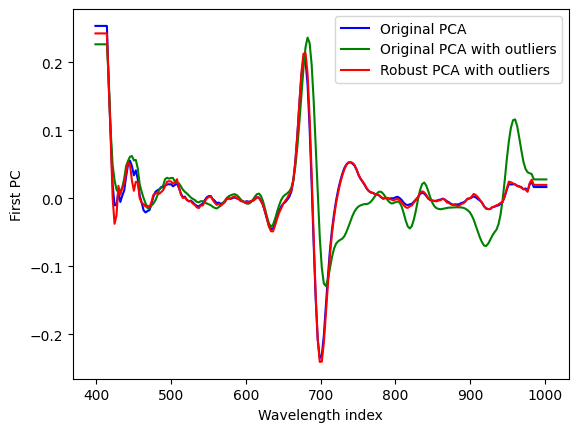

In [228]:
plt.plot(wl, pipe1["pca"].components_[0], 'b', label="Original PCA")
plt.plot(wl, pipe2["pca"].components_[0], 'g', label="Original PCA with outliers")
plt.plot(wl, first_pc_robust, 'r', label="Robust PCA with outliers")
plt.ylabel("First PC")
plt.xlabel("Wavelength index")
 
plt.legend()
plt.show()

In [229]:
support_fraction=0.3

In [230]:
from sklearn.metrics import r2_score, root_mean_squared_error

def plot_cv_vs_test(y_cal, y_cv, y_test, y_test_pred, plot_titles=["Cross-Validated Predictions", "Test Predictions"]):
    """
    Plot a comparison of cross-validated vs. test set predictions.

    Parameters
    ----------
    y_cal : array-like, shape (n_samples_cal,)
        True target values for the calibration (training) set.
    y_cv : array-like, shape (n_samples_cal,)
        Cross-validated predicted values for the calibration set.
    y_test : array-like, shape (n_samples_test,)
        True target values for the test set.
    y_test_pred : array-like, shape (n_samples_test,)
        Predicted values for the test set.
    plot_titles : list of str (2), optional
        Plot titles to use.
    """
    # Compute metrics
    r2_cv = r2_score(y_cal, y_cv)
    rmse_cv = root_mean_squared_error(y_cal, y_cv)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Prepare figure
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Combined axis limits
    all_actual = np.concatenate([y_cal, y_test])
    all_pred = np.concatenate([y_cv, y_test_pred])
    vmin = min(all_actual.min(), all_pred.min())*0.95
    vmax = max(all_actual.max(), all_pred.max())*1.05

    # Plot CV
    axs[0].scatter(y_cal, y_cv, alpha=0.6)
    axs[0].plot([vmin, vmax], [vmin, vmax], 'k--', lw=2)
    axs[0].set_title(plot_titles[0])
    axs[0].set_xlabel('Actual')
    axs[0].set_ylabel('Predicted')
    axs[0].set_aspect('equal', 'box')
    axs[0].text(0.05, 0.95, f"R² = {r2_cv:.2f}\nRMSE = {rmse_cv:.2f}",
                transform=axs[0].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Plot Test
    axs[1].scatter(y_test, y_test_pred, alpha=0.6, color='orange')
    axs[1].plot([vmin, vmax], [vmin, vmax], 'k--', lw=2)
    axs[1].set_title(plot_titles[1])
    axs[1].set_xlabel('Actual')
    axs[1].set_ylabel('Predicted')
    axs[1].set_aspect('equal', 'box')
    axs[1].text(0.05, 0.95, f"R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}",
                transform=axs[1].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Set same limits
    for ax in axs:
        ax.set_xlim(vmin, vmax)
        ax.set_ylim(vmin, vmax)

    plt.tight_layout()
    plt.show()

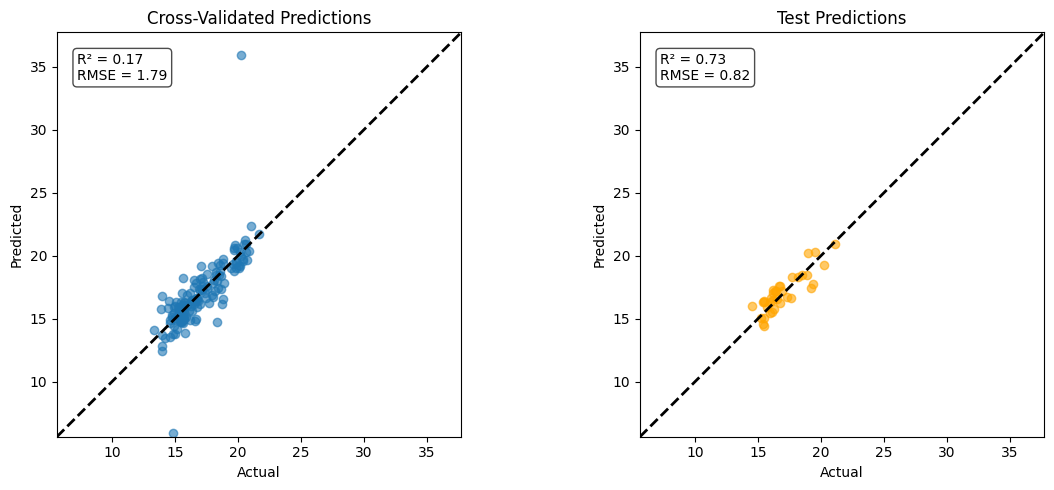

In [231]:
from sklearn import linear_model
from sklearn.model_selection import cross_val_predict

pca = PCA(random_state=42)
pc=90
standard_scaler_cal = StandardScaler()
Xstd = standard_scaler_cal.fit_transform(X_copy)
Xreg = pca.fit_transform(Xstd)[:,:pc]
model = linear_model.LinearRegression()
model.fit(Xreg, y_cal_ks)

y_cv = cross_val_predict(model, Xreg, y_cal_ks, cv=10)

X_test_std = standard_scaler_cal.transform(X_test_ks)
X_test_reg = pca.transform(X_test_std)[:,:pc]

y_test_pred = model.predict(X_test_reg)

plot_cv_vs_test(y_cal_ks, y_cv, y_test_ks, y_test_pred)

In [232]:
def robust_pcr_with_test_predefined(X_train, X_test, y_train, pc, support_fraction=0.7):
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)

    robust_cov = MinCovDet(support_fraction=support_fraction, random_state=42).fit(X_train_std)
    V_robust = robust_cov.covariance_
    values_robust, vectors_robust = np.linalg.eig(V_robust)

    sorted_indices = np.argsort(values_robust)[::-1]
    sorted_vectors = vectors_robust[:, sorted_indices]
    components = sorted_vectors[:, :pc]

    X_train_reg = np.real(X_train_std @ components)
    X_test_std = scaler.transform(X_test)
    X_test_reg = np.real(X_test_std @ components)

    regr = linear_model.LinearRegression()
    regr.fit(X_train_reg, y_train)

    y_train_cv = cross_val_predict(regr, X_train_reg, y_train, cv=10)
    y_test_pred = regr.predict(X_test_reg)

    return y_train_cv, y_test_pred

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


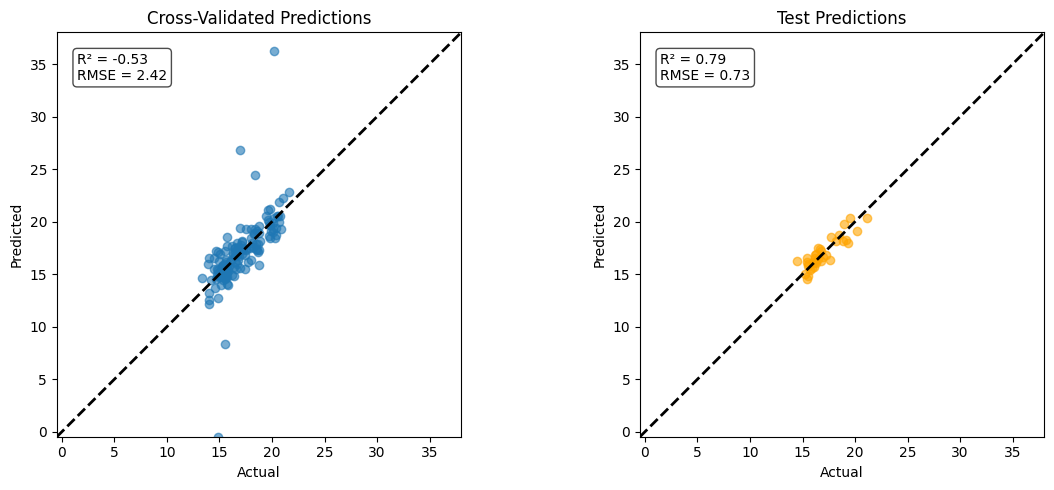

In [233]:
y_train_cv, y_test_pred = robust_pcr_with_test_predefined(X_copy, X_test_ks, y_cal_ks, support_fraction=support_fraction, pc=pc)
plot_cv_vs_test(y_cal_ks, y_train_cv, y_test_ks, y_test_pred)

We can see that the result is slightly better if we apply robust PCR. But this approach is not able to deal with outliers in response variable. And we have to guess the support fraction.

## Robust PLSR

using https://github.com/puneetmishra2/IRNPLS/tree/main

In [234]:
y_copy = np.copy(y_cal_ks)
y_copy[indices_of_outliers_y,:] = y_copy[indices_of_outliers_y,:]*2

In [235]:
import numpy as np

def irpls(X, Y, lvs, alpha):
    """
    
    Parameters:
    - X: ndarray (n_samples, n_features), predictors
    - Y: ndarray (n_samples, 1), single response
    - lvs: int, number of latent variables
    - alpha: float, tuning parameter for robustness
    
    Returns:
    - beta: list of ndarray (n_features+1, lvs), one per response
    - weights: ndarray (lvs, n_samples), diagonal weights per component
    - attributes: dict with 'T', 'Pb', 'W', 'PtW'
    """
    if X.shape[0] != Y.shape[0]:
        raise ValueError("X and Y must have the same number of samples.")
    if Y.ndim == 1:
        Y = Y.reshape(-1, 1)
    elif Y.shape[0] == 1:
        Y = Y.T


    Xorig = X.copy()
    yorig = Y.copy()
    X = X - np.median(X, axis=0)
    Y = Y - np.median(Y, axis=0)

    n_samples, n_features = X.shape
    n_responses = Y.shape[1]
    lvs = min(lvs, n_samples, n_features)

    q = np.zeros((n_responses, lvs))
    T = np.zeros((n_samples, lvs))
    weights = np.zeros((lvs, n_samples))
    w = np.zeros((n_features, lvs))
    Pb = np.zeros((n_features, lvs))

    for i in range(lvs):
        D = (np.eye(n_samples)) / n_samples
        crit = 1
        while crit > 1e-5:
            vt = X.T @ D @ Y
            v = vt.copy()
            t_temp = X @ v / np.linalg.norm(X @ v)
            q_temp = (Y.T @ D) @ t_temp
            r = Y - np.outer(t_temp, q_temp)
            lo = 1 - t_temp**2
            r = r / np.sqrt(lo)
            mad_r = np.median(np.abs(r - np.median(r, axis=0)), axis=0)
            r = r * (0.6745 / alpha) / mad_r
            temp_D = (1 - r**2)**2
            temp_D[np.abs(r) >= 1] = 0
            temp_D = np.prod(temp_D, axis=1)
            crit = np.sum(np.abs(temp_D) - np.abs(np.diag(D)))
            D = np.diag(temp_D)

        weights[i, :] = np.diag(D)
        vt = X.T @ D @ Y
        vt = vt.flatten()
        w[:, i] = vt
        t = X @ w[:, i]
        t /= np.linalg.norm(t)
        T[:, i] = t
        q[:, i] = (Y.T @ D) @ t
        Pb[:, i] = (X.T @ D) @ t
        X = X - np.outer(t, Pb[:, i])
        Y = Y - np.outer(t, q[:, i])
        w[:, i] = w[:, i] / np.linalg.norm(w[:, i])

    PtW = np.triu(Pb.T @ w)
    beta = []

    for i in range(n_responses):
        w_div_PtW = w @ np.linalg.inv(PtW)
        temp = w_div_PtW * q[i, :]  # Broadcasting
        temp_cumsum = np.cumsum(temp, axis=1)
        
        # Vectorized intercept calculation:
        intercepts = np.median(yorig[:, i]) - np.median(Xorig, axis=0) @ temp_cumsum
        beta_i_all = np.vstack([intercepts[np.newaxis, :], temp_cumsum])
        
        beta.append(beta_i_all)

    attributes = {
        'T': T,
        'Pb': Pb,
        'W': w,
        'PtW': PtW
    }

    return beta, weights, attributes

Results of normal PLS with outliers in X


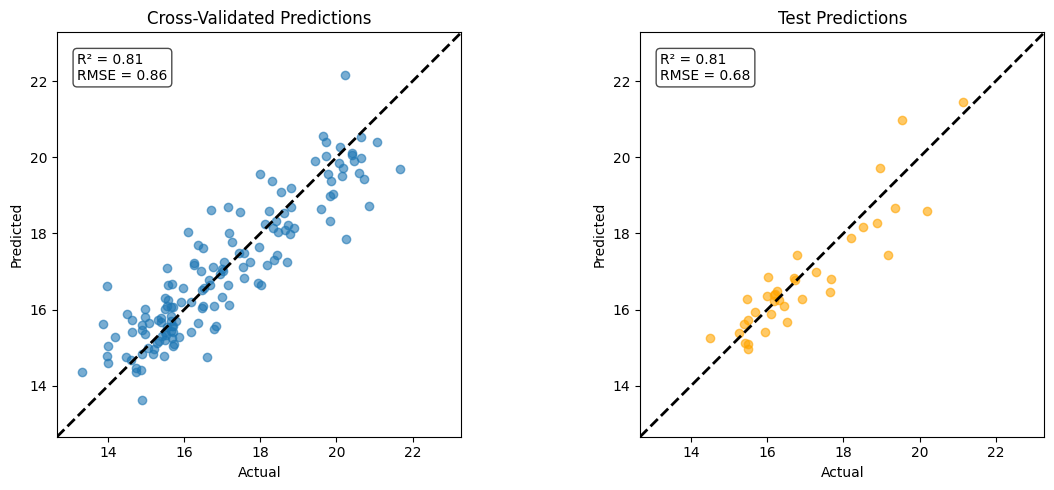

In [236]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=5)
pls.fit(X=X_copy, y=y_cal_ks)
y_pred_pls_cv = pls.predict(X_copy)
y_pred_pls_test = pls.predict(X_test_ks)
print("Results of normal PLS with outliers in X")
plot_cv_vs_test(y_cal_ks, y_pred_pls_cv, y_test_ks, y_pred_pls_test)

Results of IRPLS with outliers in X


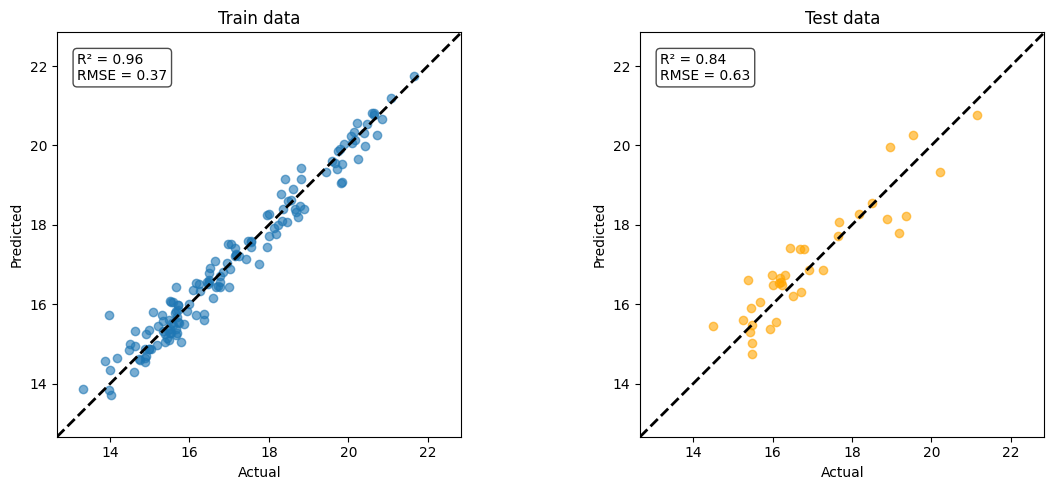

In [237]:
import matplotlib.pyplot as plt
np.expand_dims(reference_values, axis=0)

beta, weights, attributes = irpls(X_copy, y_cal_ks, lvs=30, alpha=10)

n_samples = X_cal_ks.shape[0]
n_responses = len(beta)

beta_k = beta[0][:, -1]
intercept = beta_k[0]
coefs = beta_k[1:]

Y_pred_train = X_copy @ coefs + intercept

Y_pred_test =  X_test_ks @ coefs + intercept
print("Results of IRPLS with outliers in X")
plot_cv_vs_test(y_cal_ks, Y_pred_train, y_test_ks, Y_pred_test, plot_titles=["Train data", "Test data"])

Results of normal PLS with outliers in X and Y


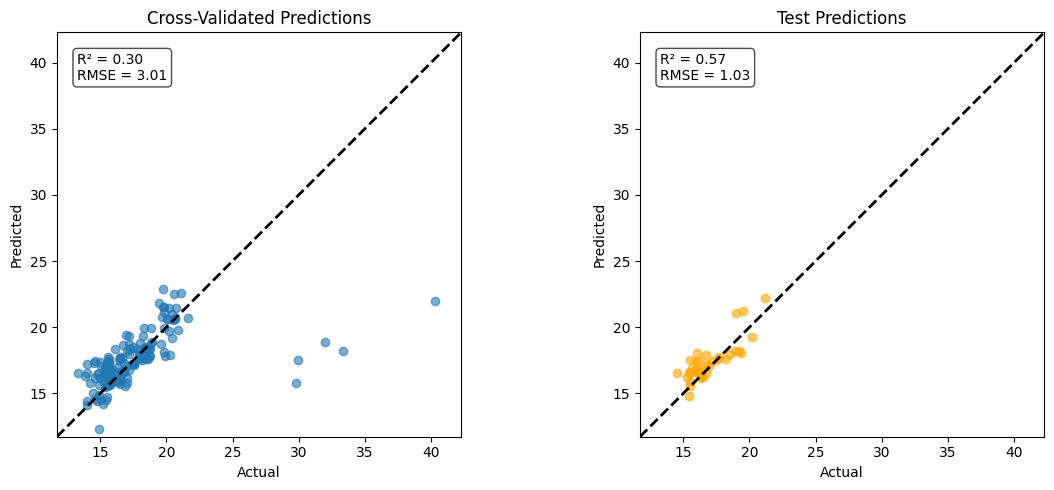

In [238]:
pls = PLSRegression(n_components=5)
pls.fit(X=X_copy, y=y_copy)
y_pred_pls_cv = pls.predict(X_copy)
y_pred_pls_test = pls.predict(X_test_ks)
print("Results of normal PLS with outliers in X and Y")
plot_cv_vs_test(y_copy, y_pred_pls_cv, y_test_ks, y_pred_pls_test)

Results of IRPLS with outliers in X and Y


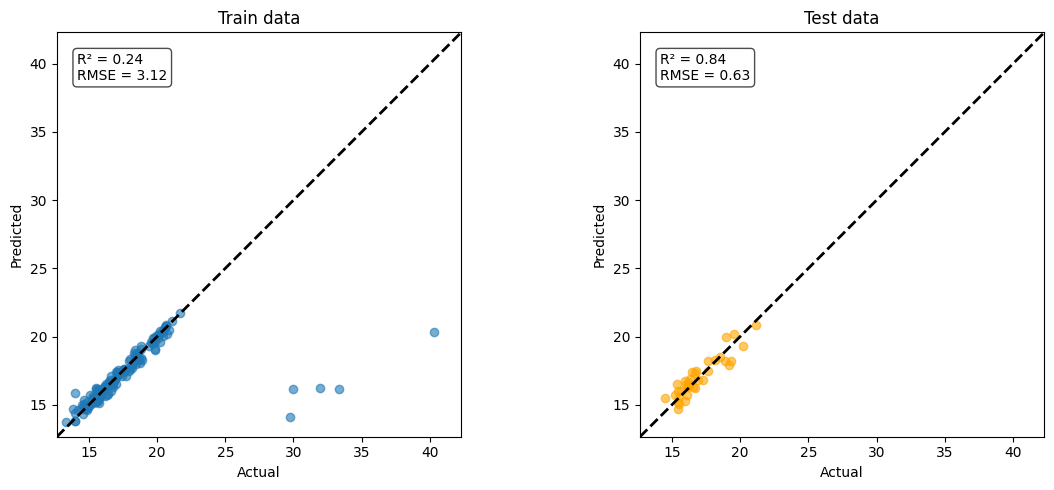

In [239]:
beta, weights, attributes = irpls(X_copy, y_copy, lvs=30, alpha=10)

n_samples = X_cal_ks.shape[0]
n_responses = len(beta)

beta_k = beta[0][:, -1]
intercept = beta_k[0]
coefs = beta_k[1:]

Y_pred_train = X_copy @ coefs + intercept

Y_pred_test =  X_test_ks @ coefs + intercept
print("Results of IRPLS with outliers in X and Y")
plot_cv_vs_test(y_copy, Y_pred_train, y_test_ks, Y_pred_test, plot_titles=["Train data", "Test data"])